<a href="https://colab.research.google.com/github/minminimithanam2025cse-dotcom/empty-repo/blob/main/LOAN_APPROVAL_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [17]:
# 1. LOAD DATASET

df = pd.read_csv("/content/Loan-Approval-Prediction.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2     

In [18]:
# 2. REMOVE LOAN_ID

# Loan_ID is only an identifier, so it is
# not useful for prediction.

df = df.drop("Loan_ID", axis=1)

In [19]:
# 3. HANDLE MISSING VALUES

# Fill categorical missing values with mode
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Fill numerical missing values with median
numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [20]:
# 4. CONVERT CATEGORICAL DATA INTO NUMBERS

df = pd.get_dummies(df, drop_first=True, dtype=int)

print("\nData after encoding:")
print(df.head())



Data after encoding:
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0       128.0             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History  Gender_Male  Married_Yes  Dependents_1  Dependents_2  \
0             1.0            1            0             0             0   
1             1.0            1            1             1             0   
2             1.0            1            1             0             0   
3             1.0            1            1             0             0   
4             1.0            1            0             0             0   

   Dependents_3+  Education_Not Graduate  Self_Employed_Yes  \
0              0                     

In [21]:
# 5. SEPARATE INPUT AND OUTPUT

# Loan_Status_Y:
# 1 = Loan Approved
# 0 = Loan Not Approved

X = df.drop("Loan_Status_Y", axis=1)
y = df["Loan_Status_Y"]

print("\nNumber of input features:", X.shape[1])


Number of input features: 14


In [22]:
# 6. TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
# 7. STANDARDIZE INPUT FEATURES

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# 8. CREATE DEEP LEARNING MODEL

model = Sequential([

    # Input layer
    tf.keras.Input(shape=(X_train.shape[1],)),

    # Hidden layer 1
    Dense(16, activation="relu"),

    # Hidden layer 2
    Dense(8, activation="relu"),

    # Output layer
    # 1 neuron because this is binary classification
    Dense(1, activation="sigmoid")
])

In [25]:
# 9. COMPILE MODEL

model.compile(

    # Adam updates weights using gradients
    optimizer="adam",

    # Binary classification loss
    loss="binary_crossentropy",

    # Measure accuracy
    metrics=["accuracy"]
)


# Display model architecture
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385 (1.50 KB)

 Trainable params: 385 (1.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# 10. TRAIN MODEL

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3980 - loss: 0.7677 - val_accuracy: 0.3434 - val_loss: 0.7970
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4617 - loss: 0.7281 - val_accuracy: 0.4141 - val_loss: 0.7628
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5153 - loss: 0.6999 - val_accuracy: 0.4545 - val_loss: 0.7378
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5612 - loss: 0.6783 - val_accuracy: 0.5253 - val_loss: 0.7164
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6071 - loss: 0.6616 - val_accuracy: 0.5455 - val_loss: 0.7012
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6276 - loss: 0.6482 - val_accuracy: 0.6061 - val_loss: 0.6881
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6403 - loss: 0.6378 - val_accuracy: 0.6162 - val_loss: 0.6762
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6556 - loss: 0.6285 - val_accuracy: 0.6364 - val_los

In [27]:
# 11. TEST MODEL

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)


Test Loss: 0.4499928951263428
Test Accuracy: 0.8373983502388


In [28]:
# 12. PREDICT FIRST TEST SAMPLE

prediction = model.predict(X_test[:1], verbose=0)

probability = prediction[0][0]

print("\nPrediction Probability:", probability)

if probability >= 0.5:
    print("Predicted Class: 1")
    print("Loan Status: APPROVED")
else:
    print("Predicted Class: 0")
    print("Loan Status: NOT APPROVED")

print("Actual Class:", y_test.iloc[0])



Prediction Probability: 0.098553784
Predicted Class: 0
Loan Status: NOT APPROVED
Actual Class: 0


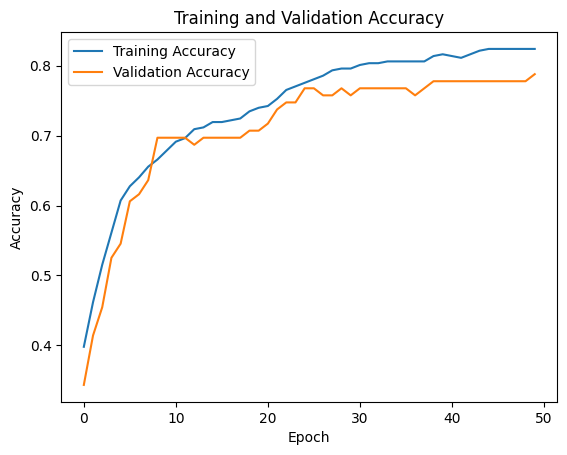

In [29]:
# 13. ACCURACY GRAPH-

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

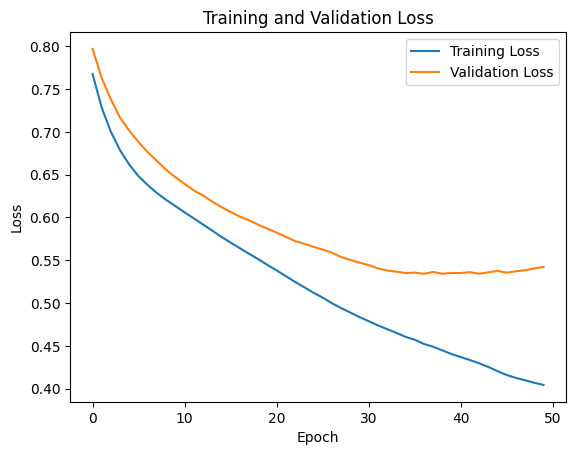

In [30]:
# 14. LOSS GRAPH

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()